# Optimizing Retail Inventory: Preventing Stockouts using EDA in Python

**Studi Kasus:** Retail Store Inventory Management
**Tujuan:** Menganalisis stok barang di gudang retail untuk mendeteksi potensi penumpukan (overstock) maupun kekurangan produk (stockout), sehingga manajemen dapat mengambil keputusan pengadaan barang yang lebih tepat.

**Dataset:** `mhs6_retail_inventory.csv` — 75 produk dari 4 kategori (Makanan, Minuman, ATK, Kosmetik), berisi data stok awal, sisa stok, unit terjual, dan harga satuan.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
os.makedirs('charts', exist_ok=True)

df = pd.read_csv('mhs6_retail_inventory.csv')
df.head()

,ID_Produk,Kategori,Stok_Awal,Sisa_Stok,Unit_Terjual,Harga_Satuan
0,PROD-001,Makanan,402,202.0,200,39500
1,PROD-002,ATK,245,169.0,76,15700
2,PROD-003,Minuman,330,317.0,13,104200
3,PROD-004,Minuman,453,2.0,451,83900
4,PROD-005,Kosmetik,467,49.0,418,107100


## 1. Identifikasi Masalah & Struktur Data

Sebelum masuk ke analisis, kita perlu memahami tipe data dari tiap kolom menggunakan `.info()`.

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75 entries, 0 to 74
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   ID_Produk     75 non-null     object 
 1   Kategori      75 non-null     object 
 2   Stok_Awal     75 non-null     int64  
 3   Sisa_Stok     65 non-null     float64
 4   Unit_Terjual  75 non-null     int64  
 5   Harga_Satuan  75 non-null     int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 3.6+ KB


**Pemetaan karakteristik data:**

| Kolom | Tipe Data Python | Karakteristik Statistik |
|---|---|---|
| ID_Produk | object | Nominal |
| Kategori | object | Nominal |
| Stok_Awal | int64 | Rasio |
| Sisa_Stok | float64 | Rasio |
| Unit_Terjual | int64 | Rasio |
| Harga_Satuan | int64 | Rasio |

Seluruh kolom numerik (Stok_Awal, Sisa_Stok, Unit_Terjual, Harga_Satuan) berskala **Rasio** karena memiliki titik nol mutlak yang bermakna (stok 0 berarti benar-benar habis). Sementara ID_Produk dan Kategori bersifat **Nominal** karena hanya berfungsi sebagai label/pengelompokan tanpa urutan tingkatan.

## 2. Statistik Deskriptif & Distribusi Awal

Cek ringkasan statistik sebelum data dibersihkan, khususnya pada kolom `Sisa_Stok` yang masih memiliki nilai kosong.

In [8]:
df[['Stok_Awal','Sisa_Stok','Unit_Terjual','Harga_Satuan']].describe()

,Stok_Awal,Sisa_Stok,Unit_Terjual,Harga_Satuan
count,75.000000,65.000000,75.000000,75.000000
mean,306.986667,128.000000,182.746667,78329.333333
std,122.530911,100.655508,123.257048,39988.527995
min,50.000000,1.000000,13.000000,7000.000000
25%,205.000000,37.000000,81.500000,46400.000000
50%,314.000000,110.000000,163.000000,80800.000000
75%,417.000000,202.000000,260.500000,105900.000000
max,499.000000,396.000000,469.000000,147800.000000


In [9]:
mean_stok = df['Sisa_Stok'].mean()
median_stok = df['Sisa_Stok'].median()
print(f"Mean Sisa_Stok : {mean_stok:.1f}")
print(f"Median Sisa_Stok: {median_stok:.1f}")
print(f"Jumlah data kosong di Sisa_Stok: {df['Sisa_Stok'].isna().sum()}")

Mean Sisa_Stok : 128.0
Median Sisa_Stok: 110.0
Jumlah data kosong di Sisa_Stok: 10


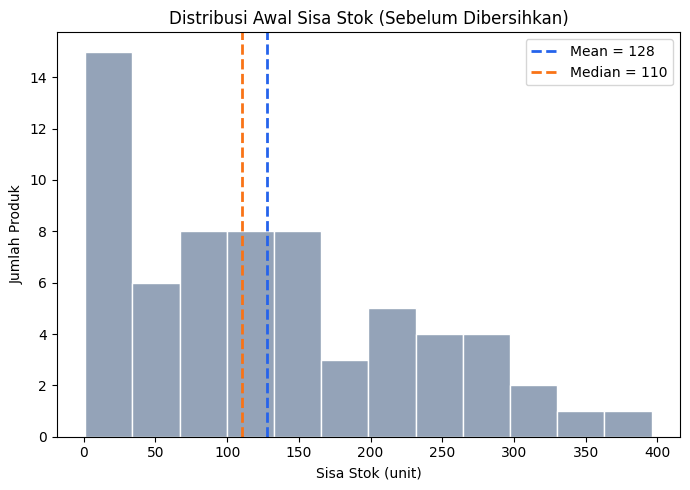

In [10]:
plt.figure(figsize=(7,5))
plt.hist(df['Sisa_Stok'].dropna(), bins=12, color='#94a3b8', edgecolor='white')
plt.axvline(mean_stok, color='#2563eb', linestyle='--', linewidth=2, label=f'Mean = {mean_stok:.0f}')
plt.axvline(median_stok, color='#f97316', linestyle='--', linewidth=2, label=f'Median = {median_stok:.0f}')
plt.title('Distribusi Awal Sisa Stok (Sebelum Dibersihkan)')
plt.xlabel('Sisa Stok (unit)')
plt.ylabel('Jumlah Produk')
plt.legend()
plt.tight_layout()
plt.savefig('charts/01_histogram_awal.png', dpi=150)
plt.show()

**Analisis kebijakan statistik:** Nilai mean (128.0) lebih besar daripada median (110.0), dengan skewness positif (+0.66). Ini menandakan distribusi sisa stok **condong ke kanan (right-skewed)** — sebagian besar produk memiliki sisa stok rendah, namun ada beberapa produk dengan sisa stok sangat tinggi yang menarik rata-rata ke atas. Dari sisi bisnis, ini mengindikasikan adanya ketimpangan: sebagian kecil produk menumpuk di gudang (overstock) sementara mayoritas produk lain stoknya menipis.

## 3. Preprocessing & Transformasi Data

### 3.1 Penanganan Data Kosong

Kolom `Sisa_Stok` memiliki 10 baris kosong. Nilai kosong ini diasumsikan terjadi karena sistem pencatatan gudang tidak mencatat stok ketika barang benar-benar habis terjual, sehingga **diisi dengan 0** (bukan dihapus).

In [11]:
df_clean = df.copy()
df_clean['Sisa_Stok'] = df_clean['Sisa_Stok'].fillna(0)

print("Sebelum  :", df['Sisa_Stok'].isna().sum(), "baris kosong")
print("Sesudah  :", df_clean['Sisa_Stok'].isna().sum(), "baris kosong")
df_clean[df['Sisa_Stok'].isna()][['ID_Produk','Kategori','Sisa_Stok']].head()

Sebelum  : 10 baris kosong
Sesudah  : 0 baris kosong


,ID_Produk,Kategori,Sisa_Stok
5,PROD-006,Minuman,0.0
12,PROD-013,Makanan,0.0
15,PROD-016,Makanan,0.0
20,PROD-021,Makanan,0.0
24,PROD-025,Kosmetik,0.0


**Justifikasi:** Jika baris dengan `Sisa_Stok` kosong langsung dihapus (*drop rows*), perusahaan berisiko kehilangan informasi penting tentang produk yang justru paling laris (karena stoknya habis total). Mengisi dengan 0 lebih masuk akal secara bisnis karena nilai kosong di sini bukan berarti "data hilang secara acak", melainkan **sinyal bahwa produk tersebut stoknya benar-benar habis** — informasi yang krusial untuk mendeteksi potensi stockout.

### 3.2 Feature Engineering: Klasifikasi Tingkat Perputaran Stok

Menggunakan `np.where()` untuk membuat kolom baru `Status_Perputaran`: produk dengan `Unit_Terjual` > 500 unit diberi label **'Fast Moving'**, sisanya **'Slow Moving'**.

In [12]:
df_clean['Status_Perputaran'] = np.where(df_clean['Unit_Terjual'] > 500, 'Fast Moving', 'Slow Moving')
df_clean[['ID_Produk','Kategori','Unit_Terjual','Status_Perputaran']].head(8)

,ID_Produk,Kategori,Unit_Terjual,Status_Perputaran
0,PROD-001,Makanan,200,Slow Moving
1,PROD-002,ATK,76,Slow Moving
2,PROD-003,Minuman,13,Slow Moving
3,PROD-004,Minuman,451,Slow Moving
4,PROD-005,Kosmetik,418,Slow Moving
5,PROD-006,Minuman,56,Slow Moving
6,PROD-007,Minuman,303,Slow Moving
7,PROD-008,Makanan,152,Slow Moving


In [13]:
df_clean['Status_Perputaran'].value_counts()

,count
Status_Perputaran,
Slow Moving,75


**Temuan menarik:** Penjualan tertinggi pada dataset ini hanya mencapai 469 unit — tidak ada satu produk pun yang melewati ambang batas 500 unit. Artinya, **seluruh 75 produk masuk kategori 'Slow Moving'** menurut standar perputaran yang ditetapkan perusahaan. Ini menjadi temuan penting tersendiri di bagian storytelling bisnis.

In [14]:
df_clean.to_csv('retail_inventory_clean.csv', index=False)
df_clean.head()

,ID_Produk,Kategori,Stok_Awal,Sisa_Stok,Unit_Terjual,Harga_Satuan,Status_Perputaran
0,PROD-001,Makanan,402,202.0,200,39500,Slow Moving
1,PROD-002,ATK,245,169.0,76,15700,Slow Moving
2,PROD-003,Minuman,330,317.0,13,104200,Slow Moving
3,PROD-004,Minuman,453,2.0,451,83900,Slow Moving
4,PROD-005,Kosmetik,467,49.0,418,107100,Slow Moving


## 4. Data Storytelling & Rekomendasi Bisnis

Agregasi total sisa stok per kategori barang untuk melihat kategori mana yang paling berisiko mengalami penumpukan.

In [15]:
agg_kategori = df_clean.groupby('Kategori')['Sisa_Stok'].sum().sort_values(ascending=False)
agg_kategori

,Sisa_Stok
Kategori,
Kosmetik,2563.0
Makanan,2281.0
Minuman,1746.0
ATK,1730.0


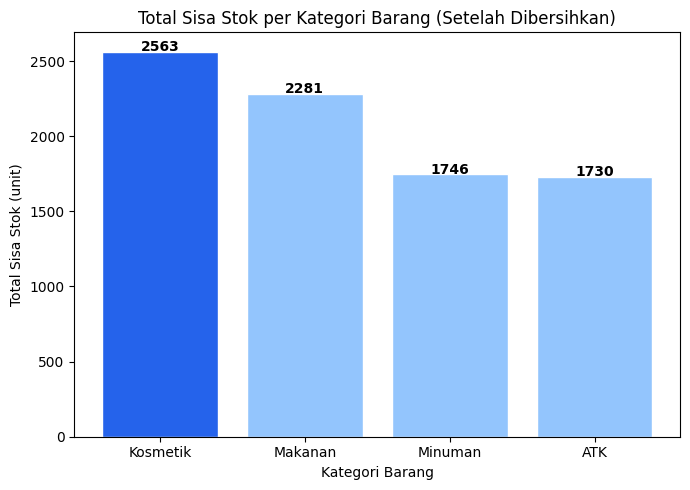

In [16]:
plt.figure(figsize=(7,5))
colors = ['#2563eb' if v == agg_kategori.max() else '#93c5fd' for v in agg_kategori.values]
bars = plt.bar(agg_kategori.index, agg_kategori.values, color=colors, edgecolor='white')
for b in bars:
    plt.text(b.get_x()+b.get_width()/2, b.get_height()+5, f'{int(b.get_height())}',
              ha='center', fontsize=10, fontweight='bold')
plt.title('Total Sisa Stok per Kategori Barang (Setelah Dibersihkan)')
plt.xlabel('Kategori Barang')
plt.ylabel('Total Sisa Stok (unit)')
plt.tight_layout()
plt.savefig('charts/02_barchart_sisa_stok_kategori.png', dpi=150)
plt.show()

### Temuan Utama (Insights)

1. **Kategori Kosmetik menyimpan sisa stok tertinggi (2.563 unit)**, diikuti Makanan (2.281 unit) — jauh di atas ATK dan Minuman. Ini mengindikasikan kategori Kosmetik berpotensi mengalami penumpukan barang (overstock) yang paling besar di gudang.
2. **Tidak ada satu pun produk yang tergolong Fast Moving** (penjualan tertinggi hanya 469 dari ambang 500 unit). Seluruh lini produk bergerak lambat secara perputaran, menandakan masalah ini bersifat menyeluruh, bukan hanya di kategori tertentu.

### Rekomendasi Tindakan

- Lakukan **evaluasi ulang volume pemesanan (re-order quantity)** khususnya untuk kategori Kosmetik dan Makanan, karena pasokan yang masuk lebih besar daripada kecepatan penjualan.
- Pertimbangkan strategi **promosi atau bundling** untuk mempercepat perputaran stok pada produk-produk yang sisa stoknya tinggi, sebelum berisiko menjadi *dead stock*.
- Tinjau kembali standar ambang batas "Fast Moving" (500 unit) karena tidak ada satu produk pun yang mencapainya — kemungkinan ambang batas tersebut terlalu tinggi untuk skala penjualan toko saat ini, atau memang menandakan performa penjualan toko sedang lemah secara keseluruhan.